In [1]:
!pip install roboflow ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.1 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="VI3MaTaF5pnkTVqhYgZQ")
project = rf.workspace("layans-workspace-8oa3f").project("denim-dh8es")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 99.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to denim-2 in yolov8:: 100%|██████████| 18755/18755 [00:03<00:00, 5613.63it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os
print(os.listdir(dataset.location))

['test', 'README.roboflow.txt', 'data.yaml', 'train', 'valid', 'README.dataset.txt']


In [4]:
import os

base_path = dataset.location

for split in ["train", "valid", "test"]:
    images_path = os.path.join(base_path, split, "images")
    labels_path = os.path.join(base_path, split, "labels")

    num_images = len(os.listdir(images_path))
    num_labels = len(os.listdir(labels_path))

    print(f"{split}: images={num_images}, labels={num_labels}")

train: images=7500, labels=7500
valid: images=938, labels=938
test: images=937, labels=937


In [5]:
import yaml

yaml_path = os.path.join(base_path, "data.yaml")

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("Number of classes:", data_config["nc"])
print("Class names:", data_config["names"])

Number of classes: 84
Class names: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '3M ESPE', '4', '5', '6', '7', '8', '9', 'AGS Medikal', 'AMerOss', 'Amalgam filling', 'Anthogyr', 'Bicon', 'BioHorizons', 'BioLife', 'Biomet 3i', 'Blue Sky Bio', 'Camlog', 'Caries', 'Composite filling', 'Cowellmedi', 'Crown', 'DENTSPLY', 'Dentatus', 'Dentis', 'Dentium', 'Euroteknika', 'Filling', 'Frontier', 'Hiossen', 'Implant', 'Implant Direct', 'Keystone Dental', 'Left sinus', 'Leone', 'MIS', 'Mandible', 'Maxilla', 'Megagen', 'Neodent', 'Neoss', 'Nobel Biocare', 'Novodent', 'NucleOSS', 'OCO Biomedical', 'OsseoLink', 'Osstem Implant', 'Periapical lesion', 'Prefabricated metal post', 'Retained root', 'Right sinus', 'Root canal filling', 'Root canal obturation', 'Sterngold', 'Straumann', 'Straumann ITI', 'Titan Implants', 'Zimmer', 'toilet']


In [6]:
from collections import Counter
import os
import yaml

base_path = dataset.location

with open(os.path.join(base_path, "data.yaml"), "r") as f:
    data_config = yaml.safe_load(f)

class_names = data_config["names"]
label_dir = os.path.join(base_path, "train", "labels")

class_counts = Counter()

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file), "r") as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

for cls_id, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls_id}: {class_names[cls_id]} -> {count}")

52: Filling -> 17641
76: Root canal filling -> 6598
9: 18 -> 4941
6: 15 -> 4935
11: 2 -> 4931
24: 31 -> 4898
25: 32 -> 4494
8: 17 -> 4465
75: Right sinus -> 4017
58: Left sinus -> 4013
7: 16 -> 3579
0: 1 -> 3377
43: Caries -> 2949
77: Root canal obturation -> 2037
35: Amalgam filling -> 1929
44: Composite filling -> 1021
12: 20 -> 972
10: 19 -> 960
23: 30 -> 955
5: 14 -> 951
13: 21 -> 944
22: 3 -> 940
21: 29 -> 936
3: 12 -> 925
4: 13 -> 920
20: 28 -> 914
30: 7 -> 911
14: 22 -> 904
27: 4 -> 900
28: 5 -> 890
17: 25 -> 888
29: 6 -> 886
1: 10 -> 882
19: 27 -> 879
15: 23 -> 870
18: 26 -> 839
32: 9 -> 818
31: 8 -> 791
2: 11 -> 782
16: 24 -> 768
46: Crown -> 694
73: Prefabricated metal post -> 409
74: Retained root -> 268
72: Periapical lesion -> 232
45: Cowellmedi -> 188
66: Nobel Biocare -> 158
42: Camlog -> 132
56: Implant Direct -> 122
38: BioHorizons -> 110
55: Implant -> 106
40: Biomet 3i -> 104
57: Keystone Dental -> 90
64: Neodent -> 84
47: DENTSPLY -> 82
51: Euroteknika -> 76
54: Hio

In [7]:
KEEP_MAP = {
    "Caries": "Caries",
    "Filling": "Filling",
    "Amalgam filling": "Filling",
    "Composite filling": "Filling",
    "Crown": "Crown",
    "Implant": "Implant",
    "Periapical lesion": "Periapical lesion",
    "Retained root": "Retained root",
    "Root canal filling": "Root canal filling",
}

FINAL_CLASSES = [
    "Caries",
    "Filling",
    "Crown",
    "Implant",
    "Periapical lesion",
    "Retained root",
    "Root canal filling",
]

NEW_CLASS_ID = {name: i for i, name in enumerate(FINAL_CLASSES)}
print(NEW_CLASS_ID)

{'Caries': 0, 'Filling': 1, 'Crown': 2, 'Implant': 3, 'Periapical lesion': 4, 'Retained root': 5, 'Root canal filling': 6}


In [8]:
KEEP_MAP = {
    "Caries": "Caries",
    "Filling": "Filling",
    "Amalgam filling": "Filling",
    "Composite filling": "Filling",
    "Crown": "Crown",
    "Implant": "Implant",
    "Periapical lesion": "Periapical lesion",
    "Retained root": "Retained root",
    "Root canal filling": "Root canal filling",
}

FINAL_CLASSES = [
    "Caries",
    "Filling",
    "Crown",
    "Implant",
    "Periapical lesion",
    "Retained root",
    "Root canal filling",
]

NEW_CLASS_ID = {name: i for i, name in enumerate(FINAL_CLASSES)}
print(NEW_CLASS_ID)

{'Caries': 0, 'Filling': 1, 'Crown': 2, 'Implant': 3, 'Periapical lesion': 4, 'Retained root': 5, 'Root canal filling': 6}


In [9]:
import os
import yaml

base_path = dataset.location
yaml_path = os.path.join(base_path, "data.yaml")

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

old_names = data_config["names"]
old_id_to_name = {i: name for i, name in enumerate(old_names)}

print("Original number of classes:", len(old_names))
print(old_id_to_name)

Original number of classes: 84
{0: '1', 1: '10', 2: '11', 3: '12', 4: '13', 5: '14', 6: '15', 7: '16', 8: '17', 9: '18', 10: '19', 11: '2', 12: '20', 13: '21', 14: '22', 15: '23', 16: '24', 17: '25', 18: '26', 19: '27', 20: '28', 21: '29', 22: '3', 23: '30', 24: '31', 25: '32', 26: '3M ESPE', 27: '4', 28: '5', 29: '6', 30: '7', 31: '8', 32: '9', 33: 'AGS Medikal', 34: 'AMerOss', 35: 'Amalgam filling', 36: 'Anthogyr', 37: 'Bicon', 38: 'BioHorizons', 39: 'BioLife', 40: 'Biomet 3i', 41: 'Blue Sky Bio', 42: 'Camlog', 43: 'Caries', 44: 'Composite filling', 45: 'Cowellmedi', 46: 'Crown', 47: 'DENTSPLY', 48: 'Dentatus', 49: 'Dentis', 50: 'Dentium', 51: 'Euroteknika', 52: 'Filling', 53: 'Frontier', 54: 'Hiossen', 55: 'Implant', 56: 'Implant Direct', 57: 'Keystone Dental', 58: 'Left sinus', 59: 'Leone', 60: 'MIS', 61: 'Mandible', 62: 'Maxilla', 63: 'Megagen', 64: 'Neodent', 65: 'Neoss', 66: 'Nobel Biocare', 67: 'Novodent', 68: 'NucleOSS', 69: 'OCO Biomedical', 70: 'OsseoLink', 71: 'Osstem Impla

In [12]:
old_to_new = {}

for old_id, old_name in old_id_to_name.items():
    if old_name in KEEP_MAP:
        merged_name = KEEP_MAP[old_name]
        old_to_new[old_id] = NEW_CLASS_ID[merged_name]

print("Mapped classes:")
for k, v in old_to_new.items():
    print(f"{k}: {old_id_to_name[k]} -> {v}: {FINAL_CLASSES[v]}")

Mapped classes:
35: Amalgam filling -> 1: Filling
43: Caries -> 0: Caries
44: Composite filling -> 1: Filling
46: Crown -> 2: Crown
52: Filling -> 1: Filling
55: Implant -> 3: Implant
72: Periapical lesion -> 4: Periapical lesion
74: Retained root -> 5: Retained root
76: Root canal filling -> 6: Root canal filling


In [13]:
import shutil

clean_base = os.path.join("/content", "denim_cleaned")

if os.path.exists(clean_base):
    shutil.rmtree(clean_base)

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(clean_base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(clean_base, split, "labels"), exist_ok=True)

print("Created:", clean_base)

Created: /content/denim_cleaned


In [14]:
from pathlib import Path

stats = {
    "train": {"kept_images": 0, "dropped_images": 0, "kept_objects": 0},
    "valid": {"kept_images": 0, "dropped_images": 0, "kept_objects": 0},
    "test": {"kept_images": 0, "dropped_images": 0, "kept_objects": 0},
}

for split in ["train", "valid", "test"]:
    src_img_dir = os.path.join(base_path, split, "images")
    src_lbl_dir = os.path.join(base_path, split, "labels")

    dst_img_dir = os.path.join(clean_base, split, "images")
    dst_lbl_dir = os.path.join(clean_base, split, "labels")

    for label_file in os.listdir(src_lbl_dir):
        src_label_path = os.path.join(src_lbl_dir, label_file)

        with open(src_label_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        new_lines = []
        for line in lines:
            parts = line.split()
            old_cls = int(parts[0])

            if old_cls in old_to_new:
                new_cls = old_to_new[old_cls]
                new_line = " ".join([str(new_cls)] + parts[1:])
                new_lines.append(new_line)
                stats[split]["kept_objects"] += 1

        if len(new_lines) == 0:
            stats[split]["dropped_images"] += 1
            continue

        image_stem = Path(label_file).stem
        possible_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
        src_image_path = None

        for ext in possible_exts:
            candidate = os.path.join(src_img_dir, image_stem + ext)
            if os.path.exists(candidate):
                src_image_path = candidate
                break

        if src_image_path is None:
            continue

        dst_image_path = os.path.join(dst_img_dir, os.path.basename(src_image_path))
        dst_label_path = os.path.join(dst_lbl_dir, label_file)

        shutil.copy2(src_image_path, dst_image_path)

        with open(dst_label_path, "w") as f:
            f.write("\n".join(new_lines) + "\n")

        stats[split]["kept_images"] += 1

print(stats)

{'train': {'kept_images': 4500, 'dropped_images': 3000, 'kept_objects': 31438}, 'valid': {'kept_images': 327, 'dropped_images': 611, 'kept_objects': 2323}, 'test': {'kept_images': 566, 'dropped_images': 371, 'kept_objects': 3974}}


In [15]:
!pip install ultralytics

In [17]:
import os
import yaml

clean_base = "/content/denim_cleaned"

FINAL_CLASSES = [
    "Caries",
    "Filling",
    "Crown",
    "Implant",
    "Periapical lesion",
    "Retained root",
    "Root canal filling",
]

clean_yaml = {
    "path": clean_base,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(FINAL_CLASSES),
    "names": FINAL_CLASSES,
}

clean_yaml_path = os.path.join(clean_base, "data.yaml")

with open(clean_yaml_path, "w") as f:
    yaml.dump(clean_yaml, f, sort_keys=False)

print("Saved cleaned data.yaml at:", clean_yaml_path)
print(clean_yaml)
print("Files in cleaned folder:", os.listdir(clean_base))

Saved cleaned data.yaml at: /content/denim_cleaned/data.yaml
{'path': '/content/denim_cleaned', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 7, 'names': ['Caries', 'Filling', 'Crown', 'Implant', 'Periapical lesion', 'Retained root', 'Root canal filling']}
Files in cleaned folder: ['test', 'data.yaml', 'train', 'valid']


In [18]:
from ultralytics import YOLO

model = YOLO("yolov8m-seg.pt")  # نرفع المستوى شوي

model.train(
    data="/content/denim_cleaned/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,  # GPU
    optimizer="AdamW",
    lr0=0.001,
    patience=10,
    workers=4,
    augment=True,
    close_mosaic=10,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    project="dental_project",
    name="yolo_clean_training"
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/denim_cleaned/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_clean_training2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fe26d124290>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04

In [19]:
model = YOLO("/content/runs/segment/dental_project/yolo_clean_training2/weights/best.pt")

In [21]:
import os

test_path = "/content/denim_cleaned/test/images"
print(os.listdir(test_path)[:10])

['4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg', '4078840000-jpg_png_jpg.rf.4877c489db8b9c79b273b64e62d18e74.jpg', '3962960000-jpg_png_jpg.rf.7f9be88460b26fa06014d919fa8c3a58.jpg', '4024800000-jpg_png_jpg.rf.4d516bc0f7ee6e1b473e005f53827a05.jpg', '4027930000-jpg_png_jpg.rf.3fc0931e3721b0575b131666bc2736d4.jpg', '587780000-jpg_png_jpg.rf.8268b06575057acf8303cbc9013b0f43.jpg', '4002350000-jpg_png_jpg.rf.f596e1047f7cae88f7b0dde32216eaf2.jpg', '2655840000-jpg_png_jpg.rf.330eca5a3c25b588dc0824c58e90ab15.jpg', '3667260000-jpg_png_jpg.rf.42ac3e3d7140a51d920059bbd372a27a.jpg', '3637060000-jpg_png_jpg.rf.52a6c5ca711be93118ea8ace42b69728.jpg']


In [22]:
results = model("/content/denim_cleaned/test/images/4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg", save=True)


image 1/1 /content/denim_cleaned/test/images/4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg: 320x640 7 Fillings, 3 Root canal fillings, 97.2ms
Speed: 3.2ms preprocess, 97.2ms inference, 10.2ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/segment/predict


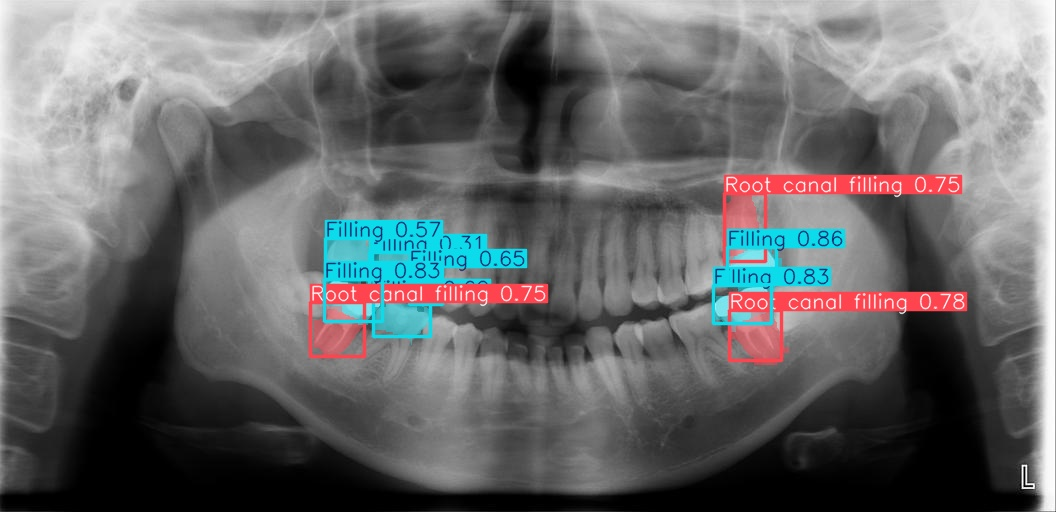

In [23]:
from IPython.display import Image, display
import os

path = "/content/runs/segment/predict/"
img = os.listdir(path)[0]

display(Image(filename=f"{path}/{img}"))

In [24]:
results = model(path, conf=0.5, save=True)


image 1/1 /content/runs/segment/predict/4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg: 320x640 (no detections), 12.9ms
Speed: 3.1ms preprocess, 12.9ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/segment/predict


In [30]:
import os

base = "/content/runs/segment/"
folders = sorted([f for f in os.listdir(base) if f.startswith("predict")])
print(folders)

['predict']


Using: /content/runs/segment/predict
['4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg']


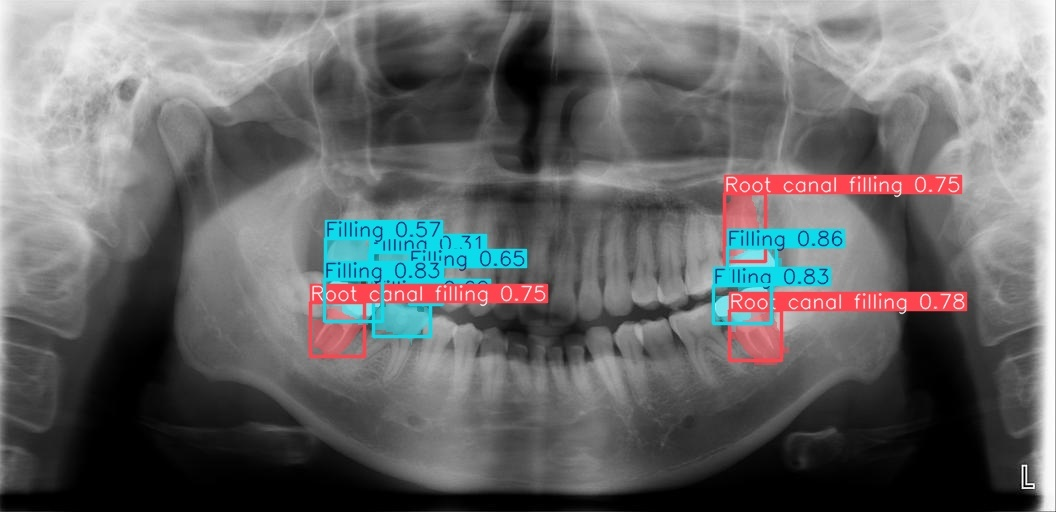

In [31]:
from IPython.display import Image, display
import os

base = "/content/runs/segment"
folders = sorted([f for f in os.listdir(base) if f.startswith("predict")])

latest = folders[-1]
path = f"{base}/{latest}"

print("Using:", path)
print(os.listdir(path))

img = os.listdir(path)[0]
display(Image(filename=f"{path}/{img}"))

In [32]:
import shutil

shutil.rmtree("/content/runs/segment/predict", ignore_errors=True)

In [35]:
img_path = "/content/denim_cleaned/test/images/4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg"

results = model(img_path, conf=0.5, save=True)


image 1/1 /content/denim_cleaned/test/images/4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg: 320x640 6 Fillings, 3 Root canal fillings, 11.6ms
Speed: 1.9ms preprocess, 11.6ms inference, 2.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/segment/predict


In [36]:
for r in results:
    print([float(c) for c in r.boxes.conf])

[0.8567835092544556, 0.8266862630844116, 0.8263624906539917, 0.782224178314209, 0.7528094053268433, 0.7477584481239319, 0.6544159054756165, 0.6220450401306152, 0.573035478591919]


['4046090000-jpg_png_jpg.rf.80bf09266da0ce51085e464800b4e147.jpg']


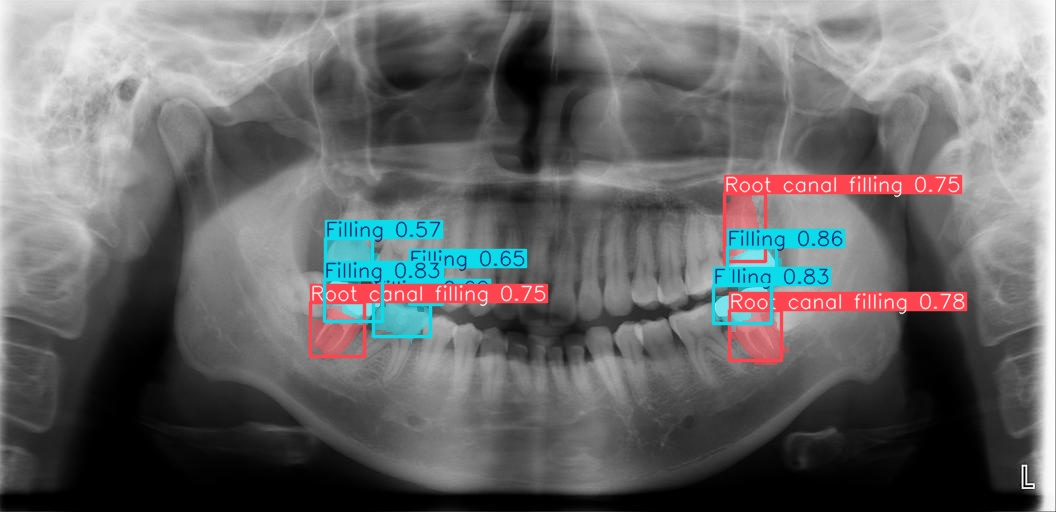

In [37]:
from IPython.display import Image, display
import os

path = "/content/runs/segment/predict"

files = os.listdir(path)
print(files)

display(Image(filename=f"{path}/{files[0]}"))

In [38]:
import os

weights_dir = "/content/runs/segment/dental_project/yolo_clean_training2/weights"
print(os.listdir(weights_dir))

['last.pt', 'best.pt']


In [39]:
from google.colab import files

files.download("/content/runs/segment/dental_project/yolo_clean_training2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import os

print(os.listdir("/content/denim_cleaned"))

['test', 'data.yaml', 'train', 'valid']


In [41]:
with open("/content/denim_cleaned/data.yaml", "r") as f:
    print(f.read())

path: /content/denim_cleaned
train: train/images
val: valid/images
test: test/images
nc: 7
names:
- Caries
- Filling
- Crown
- Implant
- Periapical lesion
- Retained root
- Root canal filling



In [44]:
from google.colab import files

files.download("/content/denim_cleaned/data.yaml")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>